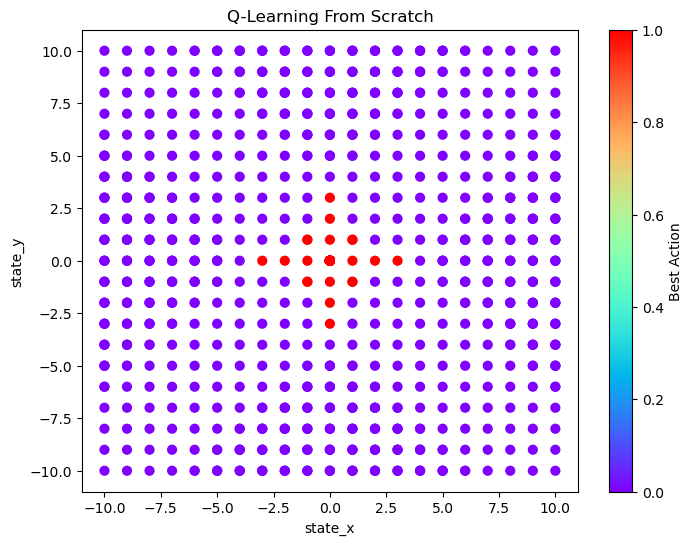

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# charger dataset
df = pd.read_csv("OptimalPolicy_angletol45.csv")

# récupérer les coordonnées des états
states = df[["state_x", "state_y"]].values

# récupérer toutes les actions uniques
actions = df["Action"].unique()

# transformer les actions en nombres
# exemple : LEFT -> 0 , RIGHT -> 1 ...
action_to_idx = {a:i for i,a in enumerate(actions)}

# nombre d'actions
n_actions = len(actions)

# créer les états uniques
unique_states = {} #dictionaire pour stocker les etats

idx = 0

for s in states:

    state_tuple = tuple(s)
    # ajouter seulement les nouveaux états
    if state_tuple not in unique_states:
        unique_states[state_tuple] = idx
        idx += 1

# nombre d'états
n_states = len(unique_states)

# creer la table Q

Q = np.zeros((n_states, n_actions))

# paramètres du q-learning
alpha = 0.1  # learning rate
gamma = 0.9  # importance des récompenses futures
epsilon = 0.1
episodes = 500

# ==========================
# entraînement
# ==========================

for episode in range(episodes):

    for i in range(len(df)-1):

        # état actuel en prenant son index
        state = tuple(states[i])
        state_idx = unique_states[state]

        # prochain état 
        next_state = tuple(states[i+1])
        next_state_idx = unique_states[next_state]

        # vraie action
        true_action = action_to_idx[df["Action"].iloc[i]]

        # exploration
        if np.random.rand() < epsilon:
            action = np.random.randint(n_actions)  # choisir une action aléatoire
        else:
            action = np.argmax(Q[state_idx])   # choisir la meilleure action

        # système de récompense
        if action == true_action:
            reward = 1 #si c est un bonne action
        else:
            reward = -1 

        # mise à jour Q-table
        Q[state_idx, action] = Q[state_idx, action] + alpha * (
            reward
            + gamma * np.max(Q[next_state_idx])
            - Q[state_idx, action]
        )

# visualisation
colors = []
# récupérer la meilleure action pour chaque point
for s in states:

    state_idx = unique_states[tuple(s)]

    best_action = np.argmax(Q[state_idx])

    colors.append(best_action)

plt.figure(figsize=(8,6))

plt.scatter(
    df["state_x"],
    df["state_y"],
    c=colors,
    cmap="rainbow",
    s=40
)

plt.xlabel("state_x")
plt.ylabel("state_y")
plt.title("Q-Learning From Scratch")

plt.colorbar(label="Best Action")

plt.show()